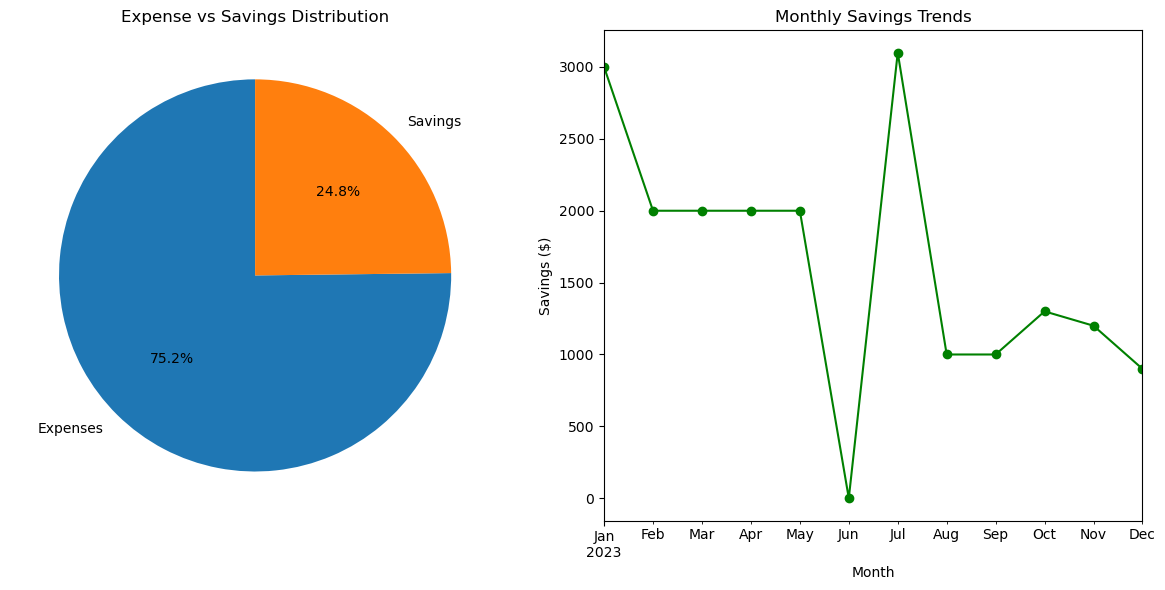

Machine IP: 10.50.15.135
Machine Name: 雷神ZERO2023
my name is Stephen


In [5]:
#stephen#
# Import necessary libraries for data manipulation, database operations, and visualization
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import socket
import platform

# Load income data from an Excel file and expenses data from a text file
income_df = pd.read_excel('income.xlsx')
expenses_df = pd.read_csv('expenses.txt', sep=' ')

# Convert the 'Month' column to datetime format for both income and expenses dataframes
income_df['Month'] = pd.to_datetime(income_df['Month'].str.strip(), format='%Y-%m-%d', errors='coerce')
expenses_df['Month'] = pd.to_datetime(expenses_df['Month'].str.strip(), format='%Y-%m-%d', errors='coerce')

# Check for invalid dates in the 'Month' column and print a warning if any are found
if income_df['Month'].isna().any():
    print("Warning: Invalid dates found in income data.")
if expenses_df['Month'].isna().any():
    print("Warning: Invalid dates found in expenses data.")

# Merge the income and expenses dataframes on the 'Month' column
merged_df = pd.merge(income_df, expenses_df, on='Month', how='inner')

# Calculate the 'Savings' column by subtracting expenses from income
merged_df['Savings'] = merged_df['Income'] - merged_df['Expenses']

# Validate that total income is greater than zero and that expenses do not exceed income
if merged_df['Income'].sum() <= 0:
    raise ValueError("Total income must be greater than zero.")
if merged_df['Expenses'].sum() > merged_df['Income'].sum():
    raise ValueError("Total expenses cannot exceed total income.")

# Calculate the percentage of income spent on expenses and the remaining savings
expense_percentage = merged_df['Expenses'].sum() / merged_df['Income'].sum() * 100
labels = ['Expenses', 'Savings']
sizes = [max(0, expense_percentage), max(0, 100 - expense_percentage)]

# Connect to a SQLite database and save the merged dataframe to a table named 'FinanceData'
conn = sqlite3.connect('finance_data.db')
merged_df.to_sql('FinanceData', conn, if_exists='replace', index=False)
conn.close()

# Create a figure with two subplots for visualizing the data
plt.figure(figsize=(12, 6))

# First subplot: Pie chart showing the distribution of expenses and savings
plt.subplot(1, 2, 1)
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Expense vs Savings Distribution')

# Second subplot: Line chart showing the trend of monthly savings over time
plt.subplot(1, 2, 2)
merged_df.sort_values('Month', inplace=True)
merged_df.set_index('Month')['Savings'].plot(kind='line', marker='o', color='green')
plt.title('Monthly Savings Trends')
plt.xlabel('Month')
plt.ylabel('Savings ($)')

# Adjust the layout to prevent overlapping and display the plots
plt.tight_layout()
plt.show()

# Function to get the machine's IP address
def get_machine_ip():
    # Get the hostname
    hostname = socket.gethostname()
    # Get the IP address
    ip_address = socket.gethostbyname(hostname)
    return ip_address

# Function to get the machine's name
def get_machine_name():
    # Get the machine name using platform
    machine_name = platform.node()
    return machine_name

# Main execution block to print the machine's IP address and name
if __name__ == "__main__":
    ip = get_machine_ip()
    name = get_machine_name()
    print(f"Machine IP: {ip}")
    print(f"Machine Name: {name}")

print("my name is Stephen")